# Kapitel 4

## Faktafrågor


1. klassificeringsproblem kännertecknas av att man behöver klassificera datan alltså lägga datan i olika kategorier. 

det används inom churning, mail sortering osv.

2. OvR är när man jämför en kategori mot alla andra kategorier. 

OvO är när man jämför en kategori mot en annan kategori. 

3. 
a) confusion matrix, rutnät där man ser en överblick på de sanna och predikterade resultaten. 

b) accuracy, kvoten mellen alla värde som modellen har inte flaggat och totala värde

c) precision, är kvoten mellan äkta predikterade sanna värde och alla predikterade sanna värde.

d) recall, är kvoten mellan predikterade sanna värde och alla sanna värde.

e) f1, är ett tal som förklarar balansen mellan precision och recall oftast vid en specifik tröskel. 

f) ROC-kurvan, är en kurva som visar modellens prestanda över alla tröskler samtidigt.

4. det betyder att om man öker precision så minskar recall och vise-versa. därför måste man hitta en fin balans och välja vad är man berädd på att offra. 

5. Logistisk regression, tar viktad summan av featuers och pressar sedan resulatet via sigmoid-funktion mellan 0 och 1. det talet i sin tur tolkas som sannolikheten att dela datan i olika klassar. 

Support vector machines, skapar en linje mellan klasserna och den linjen separerar klasserna med störst möjliga marginal. bra att använda om man har många features och för lite data. även bra mot outliers. 

Beslutsträd, tar steg för steg beslut alltså ja/nej frågor att dela för att dela upp datan i olika klasser. 

Ensemble learning, när man använder flera modeller tillsammans för att hitta det bästa genomsnitts värde från alla dessa modeller och få ännu bättre prestanda.  

Random forest, är byggt så att det är många beslutsträd men varje träd har slumpmässigt antal featues. 

Extra trees, är som randomforest men ännu mer slumpmässigt. istället för att välja den bästa splitten för varje feature, den testar olika slumpmässiga splits för olika features och sedan tar den bästa alternativen.

6. feature importance visar vilka features som generellt varit vitigast för en modell som helhet. 

## Resonemangfrågor


7. om man ökar precision då sjukner recall. öker man recall ökar false positiv som bieffekt, alltså att man vill fånga så många faktiskta positiva som möjligt även om det skulle betyda att man får flera false positiv.

Inom rättsväsendet är det bättre att man har lägre recall för att man vill inte skicka osklydiga till fängelse. 

När det gäller brandlarm är det bättre med högre recall. 


8. figuren visar logistisk regressionsmodell där modellen delar datapunkter i två klasser gul och lila med hjälp av sigmoid-funktionen som pressar värdena mellan 0 och 1 för att förklara sannolikheten av placering av datapunkter i klassar. 

9. för att vi vill inte fitta vår modell på validering och test datan, om vi gör .fit() på test eller validerings data, det är som att vi ska visa modellen facit. det är det som kallas för data leakage.

men vi skalar datan för att modellen ska inte tolka att features med stora tal är mer värdefulla än features med små tal. 

## Koduppgifter



uppgift_11



In [1]:
from sklearn.metrics import classification_report
y_true = [0, 1, 2, 2, 2]
y_pred = [0, 0, 2, 2, 1]
target_names = ['class 0', 'class 1', 'class 2']
print(classification_report(y_true, y_pred,target_names=target_names))

              precision    recall  f1-score   support

     class 0       0.50      1.00      0.67         1
     class 1       0.00      0.00      0.00         1
     class 2       1.00      0.67      0.80         3

    accuracy                           0.60         5
   macro avg       0.50      0.56      0.49         5
weighted avg       0.70      0.60      0.61         5



koden printer rapporten om f1-score, recall, precision, antal sampler och accuracy värdet för alla klasser. de två genom snitts värdena ärdena en med antal sampler och en utan, weighted är med.  

uppgift_12


In [2]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

In [3]:
tree = tree.DecisionTreeClassifier(random_state=42)
iris = load_iris()

In [4]:
clf = DecisionTreeClassifier()
clf = clf.fit(iris.data, iris.target)


uppgift_13

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import root_mean_squared_error

In [6]:
df = pd.read_excel('HR_Employee_Data.xlsx')

In [7]:
df.head()

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  str    
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  str    
 10  salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(3)
memory usage: 1.3 MB


In [9]:
df.Department.value_counts()

Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

In [10]:
df.salary.value_counts()

salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64

In [11]:
encoder = OrdinalEncoder(categories=[['low', 'medium', 'high']])
df['salary_encoded'] = encoder.fit_transform(df[['salary']])

In [12]:
df.head()

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary,salary_encoded
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low,0.0
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium,1.0
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium,1.0
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low,0.0
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low,0.0


In [13]:
df = pd.get_dummies(df, columns=['Department'], drop_first = True)

In [14]:
df.head()

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary,salary_encoded,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
0,IND02438,0.38,0.53,2,157,3,0,1,0,low,0.0,False,False,False,False,False,False,True,False,False
1,IND28133,0.80,0.86,5,262,6,0,1,0,medium,1.0,False,False,False,False,False,False,True,False,False
2,IND07164,0.11,0.88,7,272,4,0,1,0,medium,1.0,False,False,False,False,False,False,True,False,False
3,IND30478,0.72,0.87,5,223,5,0,1,0,low,0.0,False,False,False,False,False,False,True,False,False
4,IND24003,0.37,0.52,2,159,3,0,1,0,low,0.0,False,False,False,False,False,False,True,False,False


In [15]:
X = df.drop(columns=['Emp_Id', 'left', 'salary'])
y = df['left']

In [16]:
y.value_counts()

left
0    11428
1     3571
Name: count, dtype: int64

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
clf = DecisionTreeClassifier(random_state=42)

clf_hyperparams = { 
'max_depth':[None,1,5,13,20],
'min_samples_leaf':[2,4,9,22],
}

tree_cv = GridSearchCV(
    clf,
    clf_hyperparams,
    cv = 5,
    scoring= 'accuracy',
    n_jobs=-1
)

tree_cv.fit(X_train, y_train)



,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 1, ...], 'min_samples_leaf': [2, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of info

In [19]:
tree_cv.best_params_

{'max_depth': 13, 'min_samples_leaf': 2}

In [20]:
tree_cv.best_score_

np.float64(0.9770817354453245)

In [21]:
tree_cv_pred = tree_cv.predict(X_test)


In [22]:
print(classification_report(y_test, tree_cv_pred, target_names=['stay', 'left']))

              precision    recall  f1-score   support

        stay       0.98      0.98      0.98      2294
        left       0.95      0.95      0.95       706

    accuracy                           0.98      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.98      0.98      0.98      3000



In [23]:
best_clf = tree_cv.best_estimator_

In [24]:
importance = pd.DataFrame({
    'features': X.columns,
    'importance': best_clf.feature_importances_
}).sort_values('importance', ascending=False)

In [25]:
print(importance)

                  features  importance
0       satisfaction_level    0.511219
1          last_evaluation    0.149689
4       time_spend_company    0.142290
2           number_project    0.100852
3     average_montly_hours    0.083149
7           salary_encoded    0.005487
16    Department_technical    0.002127
15      Department_support    0.001564
10           Department_hr    0.000785
14        Department_sales    0.000659
5            Work_accident    0.000601
11   Department_management    0.000581
8         Department_RandD    0.000364
13  Department_product_mng    0.000263
9    Department_accounting    0.000253
12    Department_marketing    0.000099
6    promotion_last_5years    0.000016


uppgift_14

In [26]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris


In [27]:

iris = load_iris()
print(iris.DESCR)
print(iris.target_names)
X, y = load_iris(return_X_y=True, as_frame=True)


.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [28]:

X = X[iris.feature_names]
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full,
test_size=0.25, random_state=42)

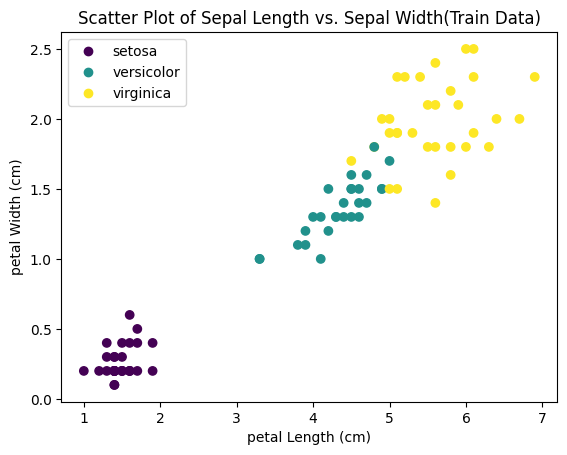

In [29]:
classes = ['setosa', 'versicolor', 'virginica']
scatter = plt.scatter(X_train['petal length (cm)'], X_train['petal width (cm)'], c=y_train)
plt.xlabel('petal Length (cm)')
plt.ylabel('petal Width (cm)')
plt.title('Scatter Plot of Sepal Length vs. Sepal Width(Train Data)')
plt.legend(handles=scatter.legend_elements()[0],labels=classes)

In [30]:
forest = RandomForestClassifier(random_state=42)

forest_hyperparams = {
    'n_estimators': [100],
    'max_depth':[None],
    'min_samples_leaf': [11]
}

forest_cv = GridSearchCV(
    forest, 
    forest_hyperparams,
    cv=5, 
    scoring='accuracy',
    n_jobs=-1
)

forest_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None], 'min_samples_leaf': [11], 'n_estimators': [100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity

In [31]:
forest_cv.best_params_

{'max_depth': None, 'min_samples_leaf': 11, 'n_estimators': 100}

In [32]:
forest_cv.best_score_

np.float64(0.9555555555555555)

In [33]:
forest_cv_pred = forest_cv.predict(X_val)

In [34]:
best_forst = forest_cv.best_estimator_

In [35]:
print(classification_report(y_val, forest_cv_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       1.00      0.91      0.95        11
   virginica       0.89      1.00      0.94         8

    accuracy                           0.97        30
   macro avg       0.96      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



In [36]:
forest_cv.fit(X_train_full, y_train_full)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None], 'min_samples_leaf': [11], 'n_estimators': [100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity

In [37]:
forest_cv_pred_test = forest_cv.predict(X_test)

rapport =classification_report(y_test, forest_cv_pred_test, target_names=iris.target_names)
print(rapport)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       1.00      1.00      1.00        12
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



uppgift_15

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [39]:
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)


In [40]:
mnist.DESCR

"**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  \n**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  \n**Please cite**:  \n\nThe MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  \n\nIt is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 

In [41]:
X,y = mnist.data, mnist.target

In [42]:
print(X.shape,y.shape)

(70000, 784) (70000,)


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [44]:
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [45]:
print("accuracy: ", model.score(X_test,y_test))

accuracy:  0.9672857142857143


In [46]:
best_model = model
best_model_pred = best_model.predict(X_test)
rapport = classification_report(y_test, best_model_pred)
print(rapport)

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1343
           1       0.98      0.98      0.98      1600
           2       0.95      0.97      0.96      1380
           3       0.96      0.95      0.96      1433
           4       0.96      0.97      0.97      1295
           5       0.97      0.96      0.97      1273
           6       0.98      0.98      0.98      1396
           7       0.97      0.97      0.97      1503
           8       0.96      0.95      0.96      1357
           9       0.96      0.95      0.95      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



True label for the plotted image is 5


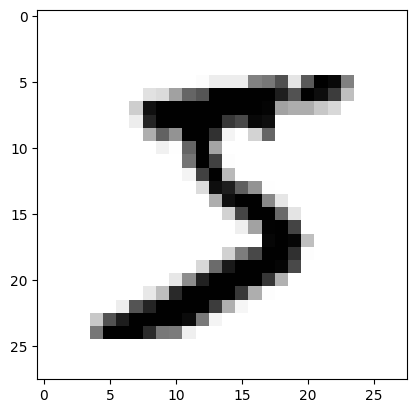

In [47]:
some_digit = X[0]
some_digit_image = some_digit.reshape(28,28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
print("True label for the plotted image is", y[0])

In [48]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:


def process_image(image):
    
    from PIL import Image, ImageFilter, ImageOps
    import numpy as np 
    import matplotlib.pyplot as plt
    import cv2

        #1. ladda bilden
    img =  Image.open(image)
    img = img.convert('L')
    # img.show()




    #2. gör om till svart och vit med threshold justering
    threshold = 100  
    img = img.point(lambda p: 255 if p > threshold else 0)
    # img.show()



    #3 invertera: byt svart och vitt
    img = ImageOps.invert(img)
    # img.show()



    #4. ta bort alla extra pixlar tills det är bara siffran kvar. 
    img_array = np.array(img)   # gör om bilden till en numpy-array (en tabell av tal) så vi kan analysera pixlarna

    # Hitta rader/kolumner som INTE är helt vita (dvs innehåller en del av siffran)
    rows = np.any(img_array > 0, axis=1)   
    cols = np.any(img_array > 0, axis=0) 

    rmin, rmax = np.where(rows)[0][[0, -1]]   # första och sista raden som innehåller siffran
    cmin, cmax = np.where(cols)[0][[0, -1]]   # första och sista kolumnen som innehåller siffran

    img = img.crop((cmin, rmin, cmax + 1, rmax + 1))   # beskär bilden till just detta område
    # img.show()
    
    



    # Förtjocka siffran MaxFilter "sprider ut" de ljusa (vita) pixlarna, gör strecken tjockare
    img = img.filter(ImageFilter.MaxFilter(size=7))   # size måste vara udda tal: 3, 5, 7...
    # img.show()


    #4. centrera siffran
    size = max(img.size)                              # tar den längsta sidan (bredd eller höjd) av den beskurna siffran
    new_size = int(size * 1.6)                         # gör en ny, större kvadratisk yta — 1.6 ger lite marginal runt siffran

    padded = Image.new('L', (new_size, new_size), 0)   # skapar en ny helt SVART kvadratisk bild

    # Räkna ut var siffran ska placeras för att hamna mitt i den nya bilden
    left = (new_size - img.width) // 2
    top = (new_size - img.height) // 2

    padded.paste(img, (left, top))   # klistrar in den beskurna siffran mitt i den nya, svarta kvadraten
    img = padded
    # img.show()



    #5. skala till 28 * 28 för att prima för modellen
    img = img.resize((28, 28), Image.LANCZOS)   # skalar om till EXAKT samma storlek som MNIST-bilderna

    img_array = np.array(img).reshape(1, -1)    # gör om till en platt lista med 784 tal (28*28), i det format modellen förväntar sig

    prediction = model.predict(img_array)
    printed_prediction = print("Modellen tror det är siffran:", prediction[0])
    # img.show()




    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(X_train[12].reshape(28, 28), cmap='gray')
    axes[0].set_title(f'Riktig MNIST (label {y_train[12]})')
    axes[1].imshow(img, cmap='gray')   # din slutgiltiga preprocessade bild från steg 5
    axes[1].set_title('Din bild')
    plt.show()







    # sannolikhet for olika siffror graf
    # Hämta sannolikheter för varje klass 
    probabilities = model.predict_proba(img_array)[0]   # [0] eftersom vi bara har EN bild, resultatet är annars en lista av listor

    digits = np.arange(10)   # siffrorna 0-9, för x-axeln

    plt.figure(figsize=(8, 4))
    bars = plt.bar(digits, probabilities, color='steelblue')

    # Markera den siffra modellen faktiskt valde med en annan färg
    predicted_digit = np.argmax(probabilities)   # index för högsta sannolikheten = modellens gissning
    bars[predicted_digit].set_color('crimson')

    plt.xlabel('Siffra')
    plt.ylabel('Sannolikhet')
    plt.title(f'Modellens sannolikhetsfördelning (gissning: {predicted_digit})')
    plt.xticks(digits)
    plt.ylim(0, 1)

    # Skriv ut exakt procent ovanför varje stapel
    for i, p in enumerate(probabilities):
        plt.text(i, p + 0.02, f'{p:.0%}', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()
    return printed_prediction

Modellen tror det är siffran: 9


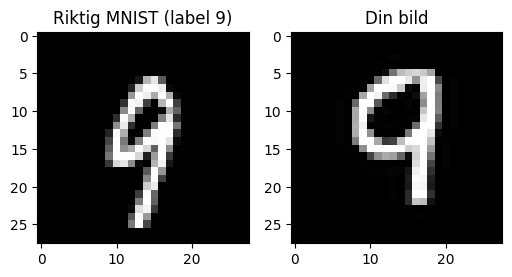

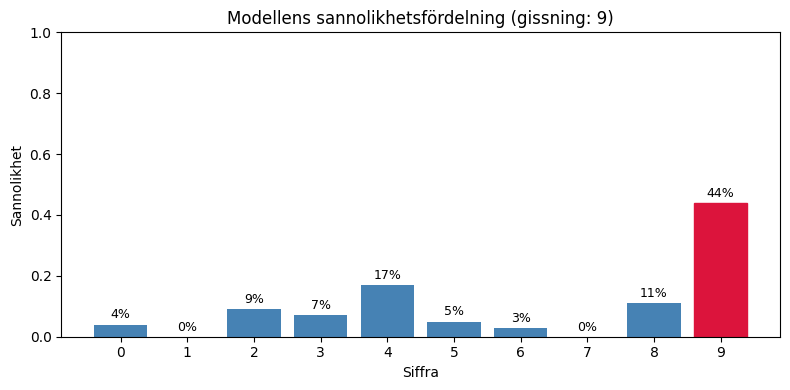

In [50]:
process_image('nine.jpeg')